### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [61]:
from tensorflow.keras import layers, Model
from tensorflow.data import experimental, Dataset

In [36]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [20]:
df = pd.read_csv('./data/auto-mpg.csv')

In [6]:
df.shape

(398, 9)

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Step 3: Exploaring Data

#### Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


In [9]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum()/ len(df)),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [10]:
feature_info

,null,null(%),unique,type
mpg,0,0.0,129,float64
cylinders,0,0.0,5,int64
displacement,0,0.0,82,float64
horsepower,0,0.0,94,object
weight,0,0.0,351,int64
acceleration,0,0.0,95,float64
model year,0,0.0,13,int64
origin,0,0.0,3,int64
car name,0,0.0,305,object


#### Target Distribution

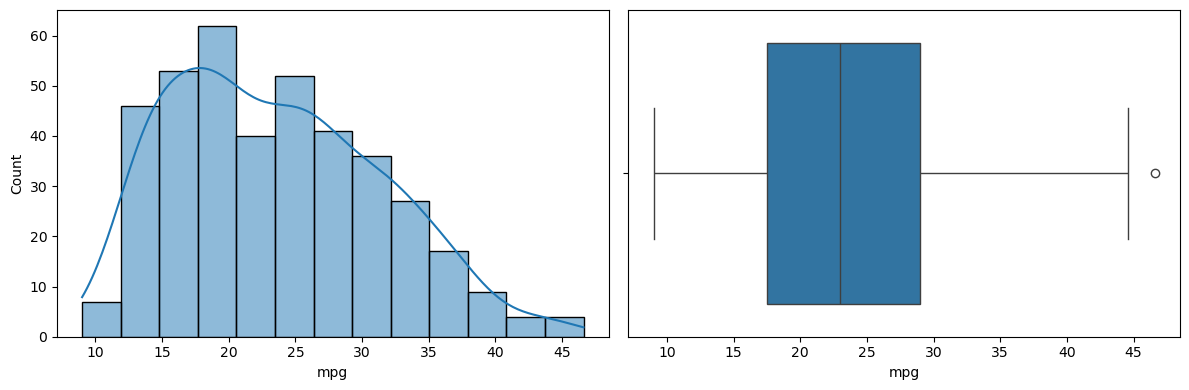

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(x='mpg', data=df, kde=True)
plt.subplot(1, 2, 2)
sns.boxplot(x='mpg', data=df, orient='h')
plt.tight_layout()

#### Discrete Distribution

In [32]:
discrete_cols = ['cylinders', 'origin']

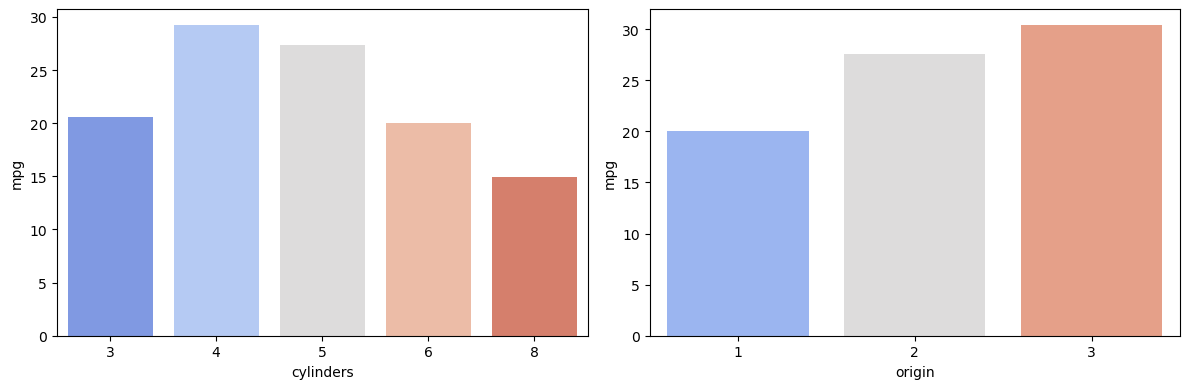

In [34]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(discrete_cols):
    plt.subplot(1, 2, i+1)
    sns.barplot(x=col, y='mpg', data=df, palette='coolwarm', errorbar=None)
plt.tight_layout()

### Step 4: Feature Engineering

#### Handling Missing Value

In [22]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce').astype('Int64')

In [31]:
df.dropna(inplace=True, ignore_index=True)

#### Heat Map

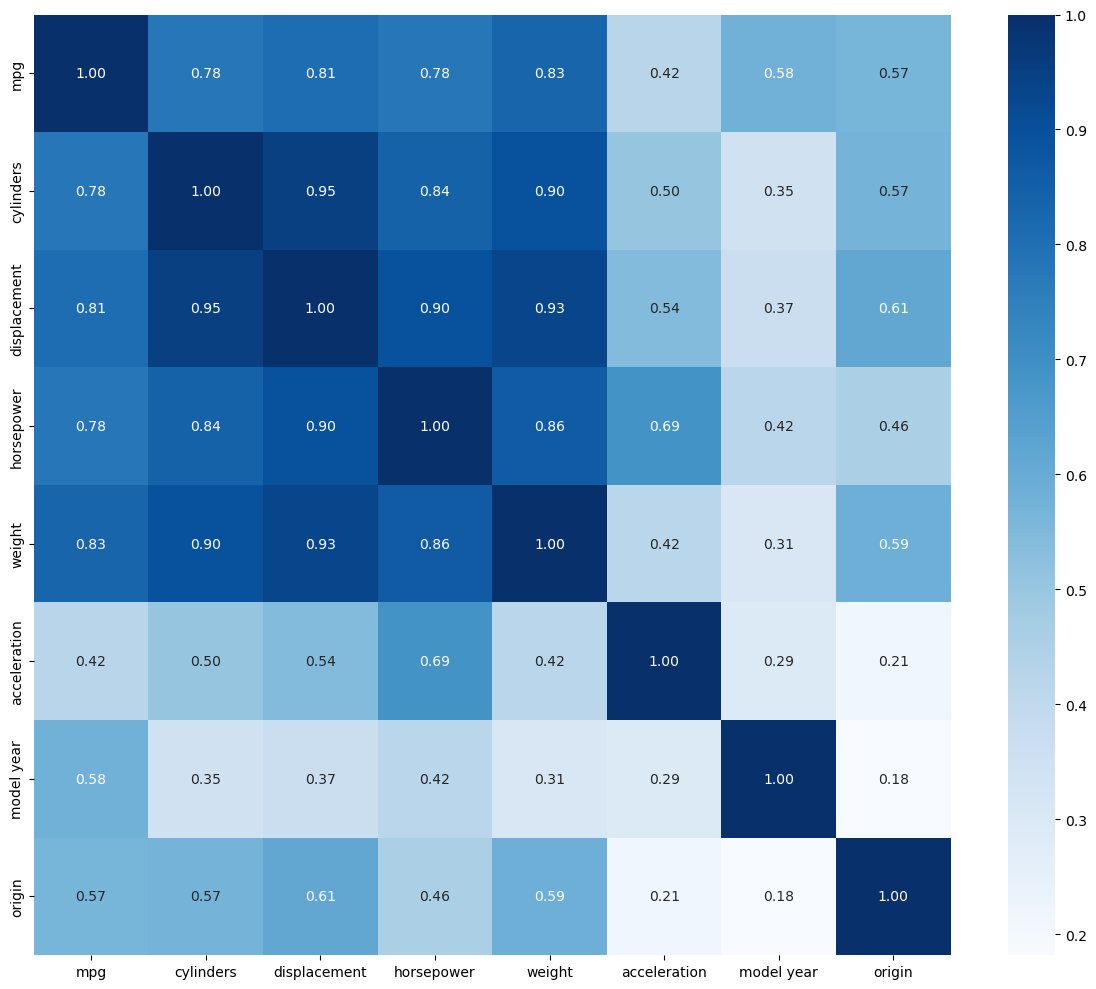

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.select_dtypes(np.number).corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [47]:
features = df.drop(['mpg', 'car name'], axis=1)
target = df['mpg']

In [48]:
raw_features = features.columns.to_list()

In [49]:
selector = SmartCorrelatedSelection(threshold=0.9, selection_method='corr_with_target')

In [50]:
features = selector.fit_transform(features, target)

In [51]:
deal_features = features.columns.to_list()

In [52]:
delete_features = list(set(raw_features) - set(deal_features))

In [53]:
print('raw features:', raw_features)
print('deal features:', deal_features)
print('delete features:', delete_features)

raw features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
deal features: ['cylinders', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
delete features: ['displacement']


#### Split Data

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [55]:
scaler = StandardScaler()

In [56]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Create Data Pipeline

In [60]:
AUTO = experimental.AUTOTUNE

In [62]:
train_ds = Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(AUTO)
test_ds = Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(AUTO)

### Step 6: Model Development

In [66]:
inputs = layers.Input(shape=(6,))
x = layers.Dense(256, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation='relu')(x)

In [67]:
model = Model(inputs, outputs)

In [68]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,889 (273.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [69]:
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)

In [70]:
history = model.fit(train_ds, epochs=50, validation_data=test_ds)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 22.0343 - mape: 94.1678 - val_loss: 22.1770 - val_mape: 97.4875
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.5969 - mape: 85.7242 - val_loss: 21.3996 - val_mape: 94.5747
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.1294 - mape: 80.6524 - val_loss: 20.6254 - val_mape: 91.6572
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.8413 - mape: 76.1035 - val_loss: 19.8563 - val_mape: 88.7473
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.6176 - mape: 71.6844 - val_loss: 19.1063 - val_mape: 85.8515
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.5289 - mape: 67.7634 - val_loss: 18.3312 - val_mape: 82.8422
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.5984 - mape: 64.5705 - val_loss: 17.4973 - val_mape: 79.5828
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.6443 - mape: 61.2922 - val_loss: 16.5636 - val_mape: 75.9240
Epoch 9/50
10/10 ━━━━━━

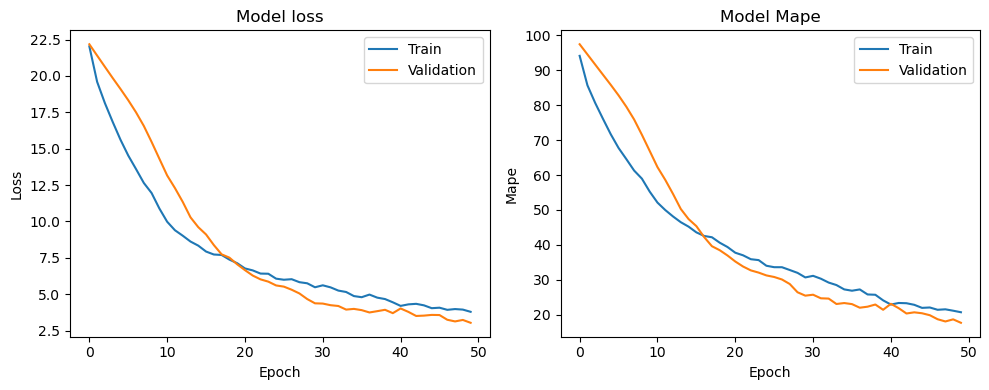

In [73]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(history.history['mape'])
plt.plot(history.history['val_mape'])
plt.title('Model Mape')
plt.ylabel('Mape')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.tight_layout()

In [75]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [84]:
print('testing r2 score:', round(metrics.r2_score(y_test, y_pred), 3))

testing r2 score: 0.577
